# Pipeline de Co-retweet — execução ponta a ponta

Roda os cinco módulos da pipeline sobre **todos os CSVs de um evento** e gera o grafo
de comunidades. Para trocar o evento, altere `EVENTO` na célula de configuração.

Etapas: **M1** carga → **M2** filtragem → **M3** matriz bipartida → **M4** projeção Jaccard
+ backbone (corte τ, em blocos) → **M5** comunidades (Leiden). Cada etapa persiste seus
artefatos em `data/processed/<evento>/` e tem uma célula de inspeção preliminar.

**Cache por estágio (idempotência).** Ao re-rodar, cada módulo (`.run(...)`) carrega do
disco se os artefatos já existem, em vez de recalcular. Para forçar o recálculo a partir de
um módulo (e todos os posteriores), ajuste `FORCE_FROM` na célula de configuração.

**Resultado final:** `graph_edges.parquet` + `graph_nodes.parquet` (M5). Os artefatos de
M1–M4 são intermediários e podem ser apagados ao final (célula de limpeza no fim).

In [1]:
import sys
from pathlib import Path

# Raiz do projeto: o notebook vive em notebooks/, mas pode rodar de notebooks/
# (Jupyter) ou da raiz do repositório (nbconvert/CI).
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))  # habilita `from modules.* import ...`

import json
import numpy as np
import pandas as pd
import scipy.sparse as sp

from modules.load import RetweetLoader
from modules.filter import NoiseFilter
from modules.bipartite import BipartiteBuilder
from modules.project import JaccardProjector
from modules.community import CommunityDetector
from modules.results import GraphResults
from modules.layout import CommunityMap
from modules.cleanup import cleanup_intermediates

## Configuração

Troque `EVENTO` para rodar a pipeline em outro conjunto de dados. Os parâmetros
em aberto (`N`, `τ`) devem ser calibrados em `notebooks/exploratory-analysis.ipynb`
antes de rodar em escala.

In [2]:
# ---- TROQUE AQUI O EVENTO ----
# Opções (subpastas de data/raw/): "invasao-3-poderes", "eleicoes",
#                                   "roberto-jefferson", "mobilizacao-0709"
EVENTO = "eleicoes"

# ---- Parâmetros da pipeline (calibrar antes de rodar em escala) ----
MIN_USER_RETWEETS = 5      # N  — filtro de atividade (mín. de retweets por usuário)
TAU = 0.10                   # τ  — peso Jaccard mínimo (backbone embutido na projeção)
BLOCK_SIZE = 2000            # usuários por bloco na projeção (controla o pico de memória)
RESOLUTION = 1.0            # resolução do Leiden

# ---- Cache por estágio ----
# Cada módulo (M1–M5) só recalcula se faltar artefato OU se for forçado aqui.
# FORCE_FROM = None  -> usa cache onde houver (cold start calcula sozinho).
# FORCE_FROM = N     -> recalcula o módulo N e TODOS os posteriores (cascata).
# Mudou N, τ ou block_size? Aponte FORCE_FROM para o módulo afetado.
FORCE_FROM = 1

def _force(n: int) -> bool:
    return FORCE_FROM is not None and n >= FORCE_FROM

RAW_DIR = PROJECT_ROOT / "data" / "raw" / EVENTO
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / EVENTO
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

assert RAW_DIR.exists(), f"Pasta do evento não encontrada: {RAW_DIR}"
csvs = sorted(RAW_DIR.glob("*.csv"))
print(f"Evento: {EVENTO}")
print(f"Raw:       {RAW_DIR}  ({len(csvs)} CSVs)")
for c in csvs:
    print(f"  - {c.name}")
print(f"Processed: {PROCESSED_DIR}")
print(f"Parâmetros: N={MIN_USER_RETWEETS}, τ={TAU}, block_size={BLOCK_SIZE}, resolution={RESOLUTION}")
print(f"FORCE_FROM: {FORCE_FROM}")

Evento: eleicoes
Raw:       /home/vinicius/tcc/data/raw/eleicoes  (1 CSVs)
  - 3010_democracia.csv
Processed: /home/vinicius/tcc/data/processed/eleicoes
Parâmetros: N=5, τ=0.1, block_size=2000, resolution=1.0
FORCE_FROM: 1


## Módulo 1 — Carga de retweets

Lê todos os CSVs do evento e mantém apenas os retweets.

In [3]:
retweets = RetweetLoader(RAW_DIR).run(out_dir=PROCESSED_DIR, force=_force(1))
print(f"Retweets carregados: {len(retweets):,}")
retweets.head()

[cache] RetweetLoader: forçado
Retweets carregados: 262,348


,author_id,referenced_tweet_id,created_at
0,79941959,1586719779691397120,2022-10-30 15:00:00
1,1577422642096881666,1586700636485197824,2022-10-30 15:00:00
2,216506332,1586551553380466690,2022-10-30 15:00:00
3,1475285308560359425,1586702852038303745,2022-10-30 15:00:00
4,119295989,1586713561019080705,2022-10-30 15:00:00


In [4]:
# Inspeção M1
print(f"Linhas (retweets):  {len(retweets):,}")
print(f"Usuários únicos:    {retweets['author_id'].nunique():,}")
print(f"Tweets únicos:      {retweets['referenced_tweet_id'].nunique():,}")
print(f"Período:            {retweets['created_at'].min()}  →  {retweets['created_at'].max()}")

Linhas (retweets):  262,348
Usuários únicos:    138,455
Tweets únicos:      8,193
Período:            2022-10-30 15:00:00  →  2022-10-30 20:59:59


## Módulo 2 — Filtragem de ruído

Remove usuários inativos (< N retweets). Tweets virais são preservados (ver D5).

In [5]:
nf = NoiseFilter(min_user_retweets=MIN_USER_RETWEETS)
filtered = nf.run(retweets, out_dir=PROCESSED_DIR, force=_force(2))
print(f"Retweets após filtro: {len(filtered):,}")
filtered.head()

[cache] NoiseFilter: forçado
Retweets após filtro: 80,132


,author_id,referenced_tweet_id,created_at
0,1475285308560359425,1586702852038303745,2022-10-30 15:00:00
1,1248072899241693185,1586662768228302849,2022-10-30 15:00:00
2,1216115695118888965,1586732387563671554,2022-10-30 15:00:03
3,252124783,1586731727707308033,2022-10-30 15:00:03
4,1562783711057555460,1586734482287206400,2022-10-30 15:00:03


In [6]:
# Inspeção M2
print(json.dumps(nf.stats, indent=2, ensure_ascii=False))
ret = len(filtered) / len(retweets) if len(retweets) else 0
print(f"\nRetenção de linhas: {len(retweets):,} -> {len(filtered):,} ({ret:.1%})")

{
  "initial": {
    "rows": 262348,
    "users": 138455,
    "tweets": 8193
  },
  "after_user_filter": {
    "rows": 80132,
    "users": 9759,
    "tweets": 4140
  }
}

Retenção de linhas: 262,348 -> 80,132 (30.5%)


## Módulo 3 — Matriz bipartida usuário × tweet

In [7]:
bg = BipartiteBuilder().run(filtered, out_dir=PROCESSED_DIR, force=_force(3))
print("Matriz B:", bg.B.shape, "| nnz:", f"{bg.B.nnz:,}")

[cache] BipartiteBuilder: forçado
Matriz B: (9759, 4140) | nnz: 80,132


In [8]:
# Inspeção M3
n_u, n_t = bg.B.shape
print(f"Usuários (linhas): {n_u:,}")
print(f"Tweets (colunas):  {n_t:,}")
print(f"Não-zeros:         {bg.B.nnz:,}")
print(f"Densidade:         {bg.B.nnz / (n_u * n_t):.2e}")
col_sum = np.asarray(bg.B.sum(axis=0)).ravel()   # retweetadores por tweet sobrevivente
print(f"Máx retweetadores num tweet sobrevivente: {int(col_sum.max()):,}")

Usuários (linhas): 9,759
Tweets (colunas):  4,140
Não-zeros:         80,132
Densidade:         1.98e-03
Máx retweetadores num tweet sobrevivente: 3,831


## Pré-voo da projeção (custo de memória)

⚠️ O custo da projeção `B·Bᵀ` cresce com o **quadrado** do nº de retweetadores do tweet
mais denso. Como os tweets virais são preservados (D5), o número de pares co-retweet pode
ser grande demais para materializar a matriz densa de uma vez — por isso a projeção é feita
em blocos, com corte do peso Jaccard durante a geração. Rode a célula abaixo **antes** do
Módulo 4 para dimensionar o custo.

In [9]:
# Pré-voo: limite superior de pares co-retweet (proxy do custo da projeção)
from math import comb

pair_upper = int(sum(comb(int(k), 2) for k in col_sum if k >= 2))
print(f"Limite superior de pares co-retweet: {pair_upper:,}")
if pair_upper > 50_000_000:
    print("\n⚠️  ALTO: materializar B·Bᵀ inteiro estouraria a memória.")
    print("    A projeção em blocos com corte de Jaccard (Módulo 4) mantém o uso")
    print("    de memória limitado e só persiste as arestas acima do limiar.")
else:
    print("OK: custo da projeção dentro do tratável.")

Limite superior de pares co-retweet: 49,020,869
OK: custo da projeção dentro do tratável.


## Módulo 4 — Projeção Jaccard + backbone (corte τ, em blocos)

Projeta a bipartida em grafo de co-retweet **e** já aplica o corte `J ≥ τ` durante a
geração (em blocos de usuários, sem materializar o `B·Bᵀ` inteiro), removendo nós que
ficaram isolados. A saída é o grafo de backbone, pronto para o Leiden.

In [10]:
pj = JaccardProjector(tau=TAU, block_size=BLOCK_SIZE)
pg = pj.run(bg, out_dir=PROCESSED_DIR, force=_force(4))
print("Backbone:", pg.W.shape, "| arestas:", f"{pg.W.nnz:,}")

[cache] JaccardProjector: forçado
Backbone: (9742, 9742) | arestas: 14,332,563


In [11]:
# Inspeção M4 — backbone (já cortado em τ; isolados removidos)
w = pg.W.data
print(json.dumps(pj.stats, indent=2))
print(f"\nNós (após remover isolados): {pg.W.shape[0]:,}")
print(f"Arestas (J >= {TAU}):        {pg.W.nnz:,}")
print(f"Peso Jaccard — min/méd/máx:  {w.min():.3f} / {w.mean():.3f} / {w.max():.3f}")

{
  "before": {
    "nodes": 9759,
    "edges": 14332563
  },
  "after": {
    "nodes": 9742,
    "edges": 14332563
  }
}

Nós (após remover isolados): 9,742
Arestas (J >= 0.1):        14,332,563
Peso Jaccard — min/méd/máx:  0.100 / 0.169 / 1.000


## Módulo 5 — Detecção de comunidades (Leiden)

Roda o Leiden sobre o backbone e grava o **resultado final** em dois parquets
autocontidos: `graph_edges.parquet` (src, dst, peso) e `graph_nodes.parquet`
(user_id, community).

In [12]:
cr = CommunityDetector(resolution=RESOLUTION).run(pg, out_dir=PROCESSED_DIR, force=_force(5))
print(f"Comunidades: {len(set(cr.membership))}")
print(f"Modularidade: {cr.partition.modularity:.4f}")
print("Resultado final salvo: graph_edges.parquet + graph_nodes.parquet")

[cache] CommunityDetector: forçado
Comunidades: 6
Modularidade: 0.1485
Resultado final salvo: graph_edges.parquet + graph_nodes.parquet


In [13]:
# Inspeção M6
sizes = pd.Series(cr.membership).value_counts()
print(f"Nº de comunidades: {len(sizes)}")
print(f"Modularidade:      {cr.partition.modularity:.4f}")
print(f"Nós no grafo:      {cr.g.vcount():,} | arestas: {cr.g.ecount():,}")
print("\nTamanho das 15 maiores comunidades:")
print(sizes.head(15).to_string())
if sizes.sum():
    print(f"\nTop 5 comunidades cobrem {sizes.head(5).sum() / sizes.sum():.1%} dos nós")

Nº de comunidades: 6
Modularidade:      0.1485
Nós no grafo:      9,742 | arestas: 14,332,563

Tamanho das 15 maiores comunidades:
1    3017
0    2788
2    2062
4    1541
3     332
5       2

Top 5 comunidades cobrem 100.0% dos nós


## Artefatos salvos

In [14]:
print(f"Arquivos em {PROCESSED_DIR}:\n")
for f in sorted(PROCESSED_DIR.glob("*")):
    print(f"  {f.name:34s} {f.stat().st_size / 1024:>10,.1f} KB")

Arquivos em /home/vinicius/tcc/data/processed/eleicoes:

  backbone_W.npz                       32,496.5 KB
  backbone_stats.json                       0.1 KB
  backbone_user_index.parquet             145.9 KB
  bipartite_B.npz                         117.4 KB
  bipartite_tweet_index.parquet            60.2 KB
  bipartite_user_index.parquet            146.3 KB
  filter_stats.json                         0.2 KB
  filtered_retweets.parquet               669.9 KB
  grafo-comunidades-drl.png               496.0 KB
  graph_edges.parquet                  31,562.1 KB
  graph_nodes.parquet                      95.2 KB
  matriz_fluxo.png                        106.0 KB
  metricas_basicas.png                     89.4 KB
  retweets.parquet                      3,845.3 KB
  run_config.json                           0.2 KB


## Resultados do grafo — matriz de fluxo + métricas

Duas peças finais (fundo branco, estilo banner), **recalculadas da base** e salvas em `processed/<evento>/`:

- **`matriz_fluxo.png`** — quanto do peso de co-amplificação fica **dentro** de cada grupo vs. **entre** grupos. Lê-se como câmara de eco: diagonal alta + off-diagonal baixa = bolhas fechadas. Simetrizada (grafo não-direcionado). Grupos numerados por tamanho; comunidades < 1% dos nós entram em "outras" (omitida da matriz quando o peso é invisível, mas seguem contadas nas métricas).
- **`metricas_basicas.png`** — nós, arestas, nº de grupos (com cobertura dos maiores), modularidade Q, assortatividade por grupo e peso intragrupo.

[cache] GraphResults: forçado
eleicoes: nós=9742  arestas=14332563  grupos=6  Q=0.1485  assort=0.2037  intra=41.92%


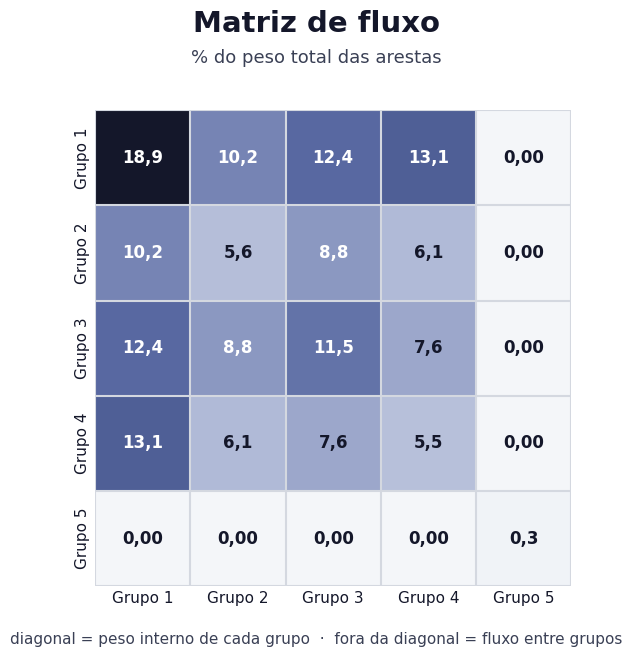

<Figure size 360x680 with 0 Axes>

In [15]:
# M6 — métricas + matriz de fluxo (peças de resultado), recalculadas da base.
# compute(cr) -> GraphMetrics (reutilizável); render() salva as 2 PNGs em processed/.
gr = GraphResults(min_frac=0.01)
metrics = gr.run(cr, out_dir=PROCESSED_DIR, force=_force(6))
print(f"{EVENTO}: nós={metrics.n_nodes}  arestas={metrics.n_edges}  grupos={metrics.n_comm}  "
      f"Q={metrics.modularity:.4f}  assort={metrics.assortativity:.4f}  intra={metrics.intra_pct:.2f}%")
_ = gr.render(metrics, PROCESSED_DIR)   # matriz_fluxo.png + metricas_basicas.png (exibidas inline)

## Mapa das comunidades — layout DRL

Posiciona cada usuário (nó) por **layout DRL**: nós que retuitaram em comum ficam próximos · cor = grupo. Para o DRL ficar tratável e as bolhas coesas (sem *hairball*), a rede é esparsificada mantendo, para cada nó, apenas suas `K` arestas mais fortes; em seguida toma-se a **componente gigante**. Salvo em `processed/<evento>/grafo-comunidades-drl.png`.

> Etapa mais cara da pipeline (DRL ~1–2 min para dezenas de milhares de nós). Rótulos numerados por tamanho (como na matriz); cores: 1 = roxo, 2 = teal, 3 = laranja…

[cache] CommunityMap: forçado
top-12/nó -> 102,326 arestas | comp.gigante=9,740 (100.0% dos nós) | DRL 30s


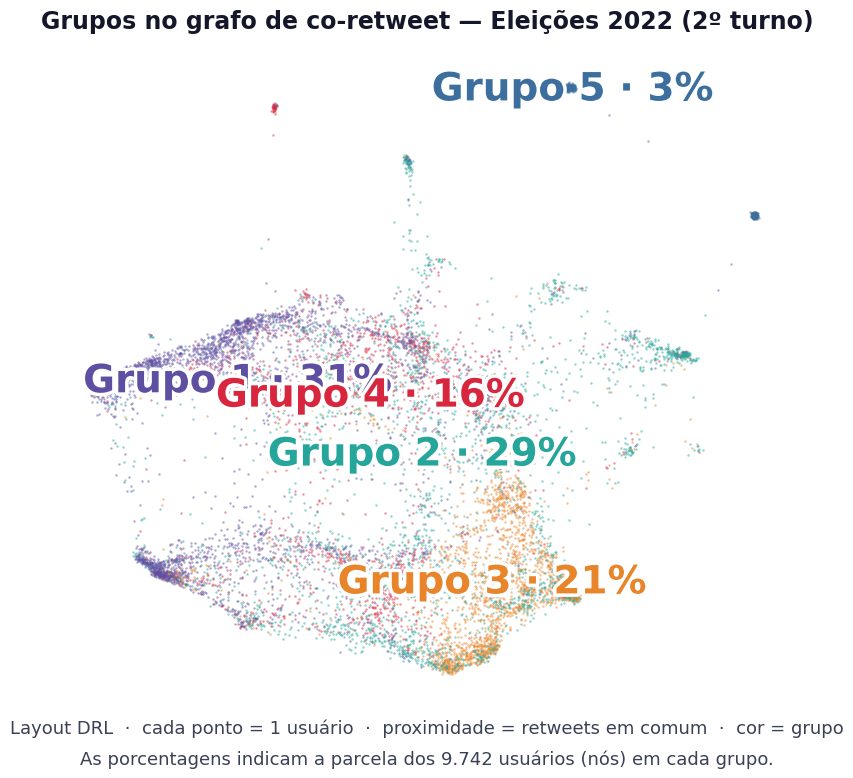

In [16]:
# M7 — mapa das comunidades por layout DRL. O Stage cacheia as COORDENADAS
# (drl_layout.*); o DRL (caro) só recalcula se faltar cache OU se _force(7).
EVENT_TITLE = {   # títulos por evento (edite à vontade) — apenas apresentação
    "invasao-3-poderes": "Invasão dos 3 Poderes (8 jan 2023)",
    "mobilizacao-0709": "Mobilização (7 set 2022)",
    "eleicoes": "Eleições 2022 (2º turno)",
    "roberto-jefferson": "Prisão de Roberto Jefferson (23 out 2022)",
}
cm = CommunityMap(top_k=12, seed=42, min_frac=0.01)
drl = cm.run(cr, out_dir=PROCESSED_DIR, force=_force(7))
_ = cm.render(drl, PROCESSED_DIR, title=EVENT_TITLE.get(EVENTO, EVENTO))   # grafo-comunidades-drl.png (inline)

## Manifesto da run

Salva `processed/<evento>/run_config.json` com os parâmetros que definem o processamento (evento, N, τ, block_size, resolução, parâmetros do layout) + carimbo de tempo. É um **entregável** — a limpeza dos intermediários não o remove.

In [17]:
# Manifesto da run: salva os parâmetros que definem este processamento, para
# reprodutibilidade. Fica em processed/<evento>/run_config.json — é um entregável
# (a limpeza não o remove).
RUN_CONFIG = {
    "evento": EVENTO,
    "min_user_retweets": MIN_USER_RETWEETS,   # N — filtro de atividade
    "tau": TAU,                               # τ — peso Jaccard mínimo (backbone)
    "block_size": BLOCK_SIZE,
    "resolution": RESOLUTION,                 # resolução do Leiden
    "force_from": FORCE_FROM,
    "layout_top_k": cm.top_k,                 # M7 — arestas/nó na esparsificação
    "layout_seed": cm.seed,
    "min_frac": cm.min_frac,                  # limiar de grupo "grande"
    "generated_at": pd.Timestamp.now().isoformat(timespec="seconds"),
}
(PROCESSED_DIR / "run_config.json").write_text(
    json.dumps(RUN_CONFIG, indent=2, ensure_ascii=False))
print("run_config.json salvo em", PROCESSED_DIR)
for k, v in RUN_CONFIG.items():
    print(f"  {k:18s} {v}")

run_config.json salvo em /home/vinicius/tcc/data/processed/eleicoes
  evento             eleicoes
  min_user_retweets  5
  tau                0.1
  block_size         2000
  resolution         1.0
  force_from         1
  layout_top_k       12
  layout_seed        42
  min_frac           0.01
  generated_at       2026-06-28T18:03:26


## Limpeza dos intermediários (opcional)

Mantém só o resultado final (`graph_edges.parquet` + `graph_nodes.parquet`) e apaga os
artefatos de M1–M4 (e órfãos de versões antigas: `projection_*`, `community_graph.graphml`).
Após apagar, re-rodar a pipeline recomputa do zero. Comece com `dry_run=True` para conferir.

In [18]:
# Troque dry_run=False para apagar de fato.
removed = cleanup_intermediates(PROCESSED_DIR, dry_run=False)
total = sum(sz for _, sz in removed)
for name, sz in removed:
    print(f"  {name:34s} {sz / 1024:>10,.1f} KB")
print(f"\n{'Liberaria' if removed else 'Nada a liberar'}: {total / 1e6:.1f} MB"
      f"  (dry_run=True — nada foi apagado)")

  filtered_retweets.parquet               669.9 KB
  filter_stats.json                         0.2 KB
  bipartite_B.npz                         117.4 KB
  bipartite_user_index.parquet            146.3 KB
  bipartite_tweet_index.parquet            60.2 KB
  backbone_W.npz                       32,496.5 KB
  backbone_user_index.parquet             145.9 KB
  backbone_stats.json                       0.1 KB
  graph_metrics.json                        1.0 KB
  drl_layout.parquet                      154.1 KB
  drl_layout.json                           0.1 KB

Liberaria: 34.6 MB  (dry_run=True — nada foi apagado)
